# PREDICTIVE ANALYSIS

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve)

## Load Dataset

In [3]:
df=pd.read_csv(r"Data\H1_cleaned_feature_engineering.csv")

In [4]:
df.head()

,Unnamed: 0,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,...,ReservationStatus,ReservationStatusDate,Total Guest,HasChildren,HasBabies,Total Stay Duration,Revenue,TotalPreviousBookings,CancellationRate,BookingChangeRate
0,0,0,342,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,2,0,0,0,0.0,0,0.0,0.008746
1,1,0,737,2015,July,27,1,0,0,2,...,Check-Out,2015-07-01,2,0,0,0,0.0,0,0.0,0.005420
2,2,0,7,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,1,0,0,1,75.0,0,0.0,0.000000
3,3,0,13,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,1,0,0,1,75.0,0,0.0,0.000000
4,4,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,2,0,0,2,196.0,0,0.0,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33967 entries, 0 to 33966
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   33967 non-null  int64  
 1   IsCanceled                   33967 non-null  int64  
 2   LeadTime                     33967 non-null  int64  
 3   ArrivalDateYear              33967 non-null  int64  
 4   ArrivalDateMonth             33967 non-null  object 
 5   ArrivalDateWeekNumber        33967 non-null  int64  
 6   ArrivalDateDayOfMonth        33967 non-null  int64  
 7   StaysInWeekendNights         33967 non-null  int64  
 8   StaysInWeekNights            33967 non-null  int64  
 9   Adults                       33967 non-null  int64  
 10  Children                     33967 non-null  int64  
 11  Babies                       33967 non-null  int64  
 12  Meal                         33967 non-null  object 
 13  Country         

## Define Features & Target

In [6]:
target = "IsCanceled"

X = df.drop(columns=[target])
y = df[target]

In [7]:
X

,Unnamed: 0,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,ReservationStatus,ReservationStatusDate,Total Guest,HasChildren,HasBabies,Total Stay Duration,Revenue,TotalPreviousBookings,CancellationRate,BookingChangeRate
0,0,342,2015,July,27,1,0,0,2,0,...,Check-Out,2015-07-01,2,0,0,0,0.00,0,0.0,0.008746
1,1,737,2015,July,27,1,0,0,2,0,...,Check-Out,2015-07-01,2,0,0,0,0.00,0,0.0,0.005420
2,2,7,2015,July,27,1,0,1,1,0,...,Check-Out,2015-07-02,1,0,0,1,75.00,0,0.0,0.000000
3,3,13,2015,July,27,1,0,1,1,0,...,Check-Out,2015-07-02,1,0,0,1,75.00,0,0.0,0.000000
4,4,14,2015,July,27,1,0,2,2,0,...,Check-Out,2015-07-03,2,0,0,2,196.00,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33962,40055,212,2017,August,35,31,2,8,2,1,...,Check-Out,2017-09-10,3,1,0,10,897.50,0,0.0,0.004695
33963,40056,169,2017,August,35,30,2,9,2,0,...,Check-Out,2017-09-10,2,0,0,11,2224.97,0,0.0,0.000000
33964,40057,204,2017,August,35,29,4,10,2,0,...,Check-Out,2017-09-12,2,0,0,14,2149.98,0,0.0,0.000000
33965,40058,211,2017,August,35,31,4,10,2,0,...,Check-Out,2017-09-14,2,0,0,14,1579.20,0,0.0,0.000000


In [8]:
y

0        0
1        0
2        0
3        0
4        0
        ..
33962    0
33963    0
33964    0
33965    0
33966    0
Name: IsCanceled, Length: 33967, dtype: int64

In [10]:
X.shape

(33967, 37)

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33967 entries, 0 to 33966
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   33967 non-null  int64  
 1   LeadTime                     33967 non-null  int64  
 2   ArrivalDateYear              33967 non-null  int64  
 3   ArrivalDateMonth             33967 non-null  object 
 4   ArrivalDateWeekNumber        33967 non-null  int64  
 5   ArrivalDateDayOfMonth        33967 non-null  int64  
 6   StaysInWeekendNights         33967 non-null  int64  
 7   StaysInWeekNights            33967 non-null  int64  
 8   Adults                       33967 non-null  int64  
 9   Children                     33967 non-null  int64  
 10  Babies                       33967 non-null  int64  
 11  Meal                         33967 non-null  object 
 12  Country                      33967 non-null  object 
 13  MarketSegment   

## Encode Categorical Variables

In [12]:
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [13]:
X

,Unnamed: 0,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,ReservationStatus,ReservationStatusDate,Total Guest,HasChildren,HasBabies,Total Stay Duration,Revenue,TotalPreviousBookings,CancellationRate,BookingChangeRate
0,0,342,2015,5,27,1,0,0,2,0,...,1,108,2,0,0,0,0.00,0,0.0,0.008746
1,1,737,2015,5,27,1,0,0,2,0,...,1,108,2,0,0,0,0.00,0,0.0,0.005420
2,2,7,2015,5,27,1,0,1,1,0,...,1,109,1,0,0,1,75.00,0,0.0,0.000000
3,3,13,2015,5,27,1,0,1,1,0,...,1,109,1,0,0,1,75.00,0,0.0,0.000000
4,4,14,2015,5,27,1,0,2,2,0,...,1,110,2,0,0,2,196.00,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33962,40055,212,2017,1,35,31,2,8,2,1,...,1,910,3,1,0,10,897.50,0,0.0,0.004695
33963,40056,169,2017,1,35,30,2,9,2,0,...,1,910,2,0,0,11,2224.97,0,0.0,0.000000
33964,40057,204,2017,1,35,29,4,10,2,0,...,1,911,2,0,0,14,2149.98,0,0.0,0.000000
33965,40058,211,2017,1,35,31,4,10,2,0,...,1,912,2,0,0,14,1579.20,0,0.0,0.000000


In [14]:
X.shape

(33967, 37)

In [17]:
X.dtypes

Unnamed: 0                       int64
LeadTime                         int64
ArrivalDateYear                  int64
ArrivalDateMonth                 int64
ArrivalDateWeekNumber            int64
ArrivalDateDayOfMonth            int64
StaysInWeekendNights             int64
StaysInWeekNights                int64
Adults                           int64
Children                         int64
Babies                           int64
Meal                             int64
Country                          int64
MarketSegment                    int64
DistributionChannel              int64
IsRepeatedGuest                  int64
PreviousCancellations            int64
PreviousBookingsNotCanceled      int64
ReservedRoomType                 int64
AssignedRoomType                 int64
BookingChanges                   int64
DepositType                      int64
DaysInWaitingList                int64
CustomerType                     int64
ADR                            float64
RequiredCarParkingSpaces 

## Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train

array([[-1.10863044, -0.72214037, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [ 0.58935501,  0.51144989, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [ 0.33671026,  0.6315339 , -0.19500789, ..., -0.16575262,
        -0.11207832, -0.10484305],
       ...,
       [ 0.51821694,  0.74070117, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [ 1.2396232 , -0.87497456,  1.19579248, ...,  0.67423169,
        -0.11207832, -0.17665657],
       [-0.6869456 , -0.89680801,  1.19579248, ..., -0.16575262,
        -0.11207832, -0.17665657]], shape=(27173, 37))

In [21]:
X_test

array([[-1.01552326, -0.70030691, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [ 1.65136963, -0.86405783,  1.19579248, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [-0.12211284, -0.90772474, -1.58580826, ..., -0.16575262,
        -0.11207832, -0.17665657],
       ...,
       [ 0.35423324,  0.59878371, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [-1.21124012,  2.09437544, -0.19500789, ..., -0.16575262,
        -0.11207832, -0.17665657],
       [ 0.25946966, -0.86405783, -0.19500789, ...,  0.67423169,
        -0.11207832, -0.17665657]], shape=(6794, 37))

## Train Logistic Regression Model

In [22]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Predictions

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [24]:
y_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(6794,))

In [25]:
y_prob

array([9.82485165e-01, 5.30710026e-03, 7.97993465e-04, ...,
       4.28818782e-04, 9.99981229e-01, 3.19521654e-06], shape=(6794,))

## Evaluation Metrics

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9908743008536944
Precision: 0.9916613213598461
Recall: 0.9692789968652038
ROC-AUC: 0.9938019187437178

Confusion Matrix:
 [[5186   13]
 [  49 1546]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      5199
           1       0.99      0.97      0.98      1595

    accuracy                           0.99      6794
   macro avg       0.99      0.98      0.99      6794
weighted avg       0.99      0.99      0.99      6794



## ROC Curve

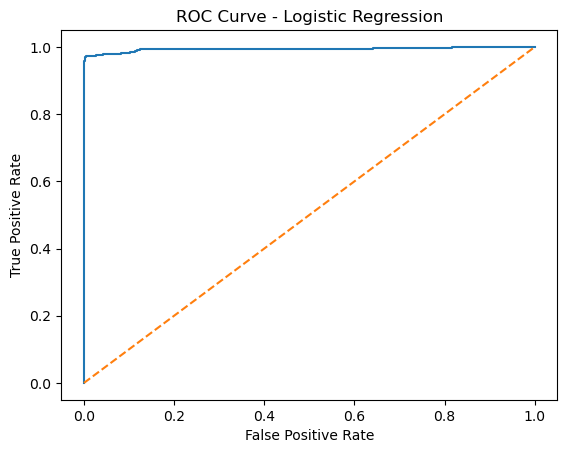

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

## Train Decision Tree

In [28]:
dt_model = DecisionTreeClassifier(
    max_depth=5,         # control overfitting
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions

In [29]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [30]:
y_pred_dt

array([1, 0, 0, ..., 0, 1, 0], shape=(6794,))

In [31]:
y_prob_dt

array([1., 0., 0., ..., 0., 1., 0.], shape=(6794,))

## Evaluation Metrics

In [32]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0

Confusion Matrix:
 [[5199    0]
 [   0 1595]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5199
           1       1.00      1.00      1.00      1595

    accuracy                           1.00      6794
   macro avg       1.00      1.00      1.00      6794
weighted avg       1.00      1.00      1.00      6794



## ROC Curve

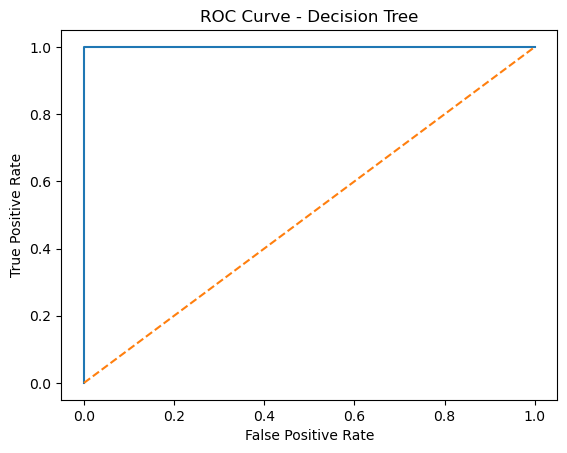

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()